# 03 - DMN-lite Training

This notebook documents the first working model-training step of the project.

The paper trains a Deep Momentum Network with an LSTM and a Sharpe-ratio objective. For the current deadline, we implement a lighter and fully reproducible approximation: a ridge model that maps momentum, volatility, relative-return and CPD features to bounded stock positions.

The goal is to close the full pipeline: features + CPD -> model -> positions -> backtest. The full LSTM remains the natural next extension.

In [1]:
import sys
from pathlib import Path

sys.modules.setdefault("numexpr", None)
sys.modules.setdefault("bottleneck", None)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "stoxx600"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 110})

## Reproducible Training Command

The source of truth for this step is `scripts/03_train_dmn.py`. The cell below is intentionally optional because the full training run already produced the output files used in this notebook.

In [2]:
RUN_TRAINING = False

if RUN_TRAINING:
    import subprocess
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "scripts" / "03_train_dmn.py")],
        cwd=PROJECT_ROOT,
        check=True,
    )

## Model Design

The DMN-lite model uses an expanding walk-forward protocol. For each test year, the model is fitted only on dates strictly before that year, then predicts positions for the next year.

Main features:

- medium and slow momentum returns: 21d, 63d, 126d, 252d;
- realized volatility: 20d, 60d, 252d;
- idiosyncratic return proxies: returns versus equal-weight market and sector;
- CPD ensemble score when available.

In [3]:
folds = pd.read_csv(DATA_DIR / "dmn_lite_fold_summary.csv", parse_dates=["train_start", "train_end", "test_start", "test_end"])
folds.tail(8)

,fold_year,train_rows,test_rows,train_start,train_end,test_start,test_end,train_objective_sharpe_loss,avg_abs_position
9,2019,904318,54087,2006-03-27,2018-12-28,2019-01-02,2019-12-30,-0.387800,0.161424
10,2020,953734,63800,2006-03-27,2019-12-30,2020-01-02,2020-12-30,-0.385447,0.203316
11,2021,1010837,101168,2006-03-27,2020-12-30,2021-01-04,2021-12-30,-0.389272,0.210789
12,2022,1100485,88547,2006-03-27,2021-12-30,2022-01-03,2022-12-30,-0.397603,0.166663
13,2023,1183465,128244,2006-03-27,2022-12-30,2023-01-02,2023-12-29,-0.377704,0.186216
14,2024,1300372,109891,2006-03-27,2023-12-29,2024-01-02,2024-12-30,-0.361505,0.146256
15,2025,1407284,155865,2006-03-27,2024-12-30,2025-01-01,2025-12-31,-0.341396,0.169926
16,2026,1551504,42984,2006-03-27,2025-12-31,2026-01-01,2026-04-10,-0.339748,0.175394


In [4]:
positions = pd.read_csv(
    DATA_DIR / "dmn_lite_positions.csv",
    usecols=["date", "ticker", "dmn_lite_position", "model_score", "fold_year"],
    parse_dates=["date"],
)

print(f"Positions: {len(positions):,} rows")
print(f"Tickers: {positions['ticker'].nunique():,}")
print(f"Date range: {positions['date'].min().date()} -> {positions['date'].max().date()}")
positions[["dmn_lite_position", "model_score"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

Positions: 1,332,307 rows
Tickers: 814
Date range: 2010-01-04 -> 2026-04-10


,dmn_lite_position,model_score
count,1.332307e+06,1.332307e+06
mean,1.243119e-01,1.301086e-02
std,1.704766e-01,2.069917e-02
min,-9.999912e-01,-6.167472e-01
1%,-3.340271e-01,-3.473543e-02
5%,-1.636996e-01,-1.651858e-02
50%,1.331622e-01,1.339577e-02
95%,3.756262e-01,3.949576e-02
99%,5.499976e-01,6.183778e-02
max,9.999841e-01,5.871680e-01


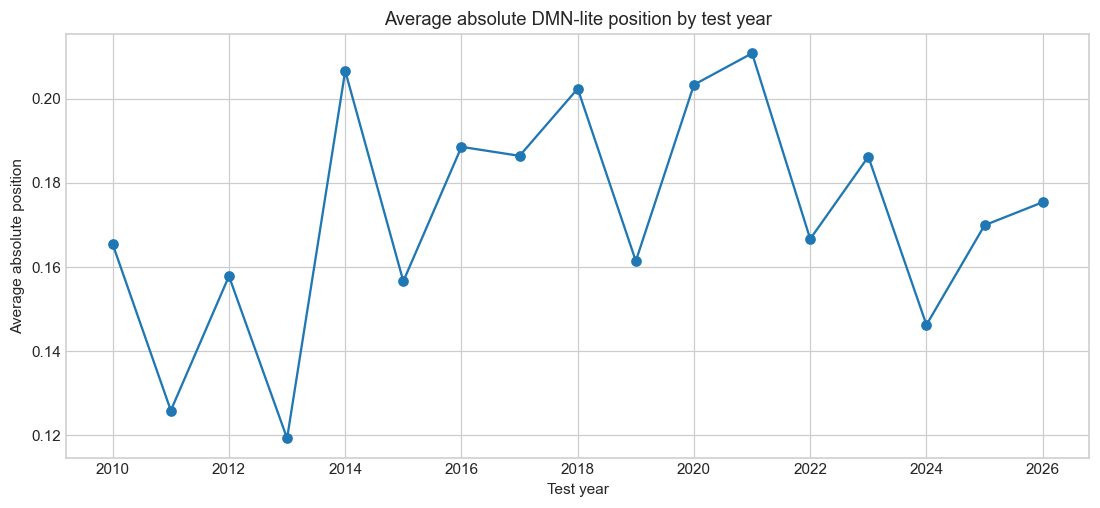

In [5]:
fig, ax = plt.subplots()
ax.plot(folds["fold_year"], folds["avg_abs_position"], marker="o")
ax.set_title("Average absolute DMN-lite position by test year")
ax.set_xlabel("Test year")
ax.set_ylabel("Average absolute position")
plt.show()

## Interpretation

This model is not presented as a final reproduction of the LSTM architecture. It is a first supervised allocation layer that keeps the same economic inputs as the paper and produces out-of-sample stock positions. This gives us a clean baseline before implementing the heavier LSTM/Sharpe-loss version.